In [1]:
import pandas as pd
import sklearn.impute as skl_imp
from sklearn.experimental import enable_iterative_imputer
from sklearn.preprocessing import PowerTransformer

from Funciones import *

In [2]:
# Abrir archivo raw_data
data_folder = "../../data/stocks"
df = pd.read_parquet(f"{data_folder}/raw_data.parquet")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Ticker               100 non-null    object 
 1   Sector               100 non-null    object 
 2   MarketCap            100 non-null    int64  
 3   Beta                 100 non-null    float64
 4   DividendYield        89 non-null     float64
 5   ForwardPE            100 non-null    float64
 6   trailingPegRatio     95 non-null     float64
 7   PriceToBook          100 non-null    float64
 8   EnterpriseToEbitda   89 non-null     float64
 9   ReturnOnAssets       100 non-null    float64
 10  returnOnEquity       95 non-null     float64
 11  profitMargins        100 non-null    float64
 12  operatingMargins     100 non-null    float64
 13  currentRatio         94 non-null     float64
 14  debtToEquity         87 non-null     float64
 15  revenueGrowth        100 non-null    floa

# Variables continuas

In [4]:
# Formatear market cap en billions
df["MarketCap"] = df["MarketCap"] / 10**9

In [5]:
df.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
MarketCap,100.0,423.28,766.98,23.88,97.22,177.13,333.75,4321.92
Beta,100.0,0.89,0.47,0.01,0.42,0.91,1.22,2.38
DividendYield,89.0,2.25,1.49,0.02,0.89,2.22,3.01,6.52
ForwardPE,100.0,19.98,15.09,5.42,12.80,18.23,21.87,141.16
trailingPegRatio,95.0,2.41,2.16,0.40,1.24,1.82,2.75,13.77
PriceToBook,100.0,17.83,140.98,-130.23,1.92,4.30,8.95,1396.42
EnterpriseToEbitda,89.0,18.64,19.43,-64.61,11.40,16.07,21.44,139.02
ReturnOnAssets,100.0,0.08,0.07,-0.02,0.03,0.06,0.11,0.51
returnOnEquity,95.0,1.02,6.38,-0.20,0.11,0.20,0.38,62.25
profitMargins,100.0,0.18,0.13,-0.23,0.08,0.16,0.28,0.56


In [25]:
# Coeficientes de asimetria
df.select_dtypes(include="number").skew()

Beta                          0.439538
DividendYield                 0.985296
EnterpriseToEbitda            2.577394
ReturnOnAssets                2.574613
profitMargins                 0.089155
operatingMargins              0.425455
currentRatio                  2.838487
revenueGrowth                 2.214416
shortPercentOfFloat           2.827094
PriceToBook_Transformed       1.990294
returnOnEquity_Transformed    0.124257
ForwardPE_log                 0.709529
MarketCap_log                 0.791824
debtToEquity_log             -0.352076
trailingPegRatio_log          0.269973
dtype: float64

Cont


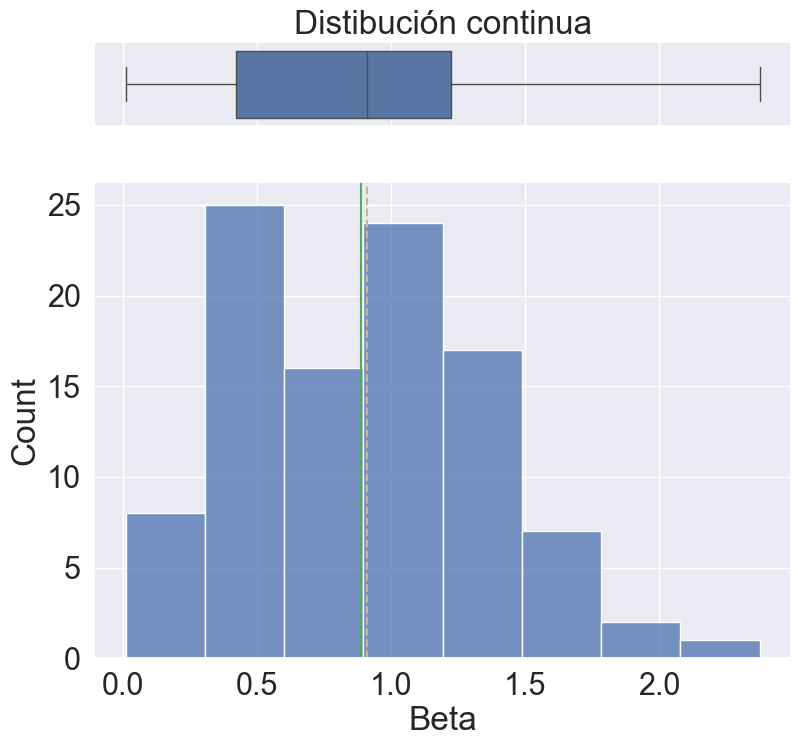

In [26]:
# Graficar
plot(df['Beta'])

In [10]:
# Variable: PriceToBook

# Transformar
pt = PowerTransformer(method='yeo-johnson', standardize=True)
df['PriceToBook_Transformed'] = pt.fit_transform(df[['PriceToBook']])

# Elimino la columna sin transformar
df.drop('PriceToBook', axis=1, inplace=True)

In [12]:
# Variable: returnOnEquity

df['returnOnEquity_Transformed'] = pt.fit_transform(df[['returnOnEquity']])
df.drop('returnOnEquity', axis=1, inplace=True)

In [14]:
# Variable: ForwardPE

df['ForwardPE_log'] = np.log(df['ForwardPE'])
df.drop('ForwardPE', axis=1, inplace=True)

In [15]:
# Variable: MarketCap
df['MarketCap_log'] = np.log(df['MarketCap'])
df.drop('MarketCap', axis=1, inplace=True)

In [16]:
# Variable: debtToEquity
df['debtToEquity_log'] = np.log(df['debtToEquity'])
df.drop('debtToEquity', axis=1, inplace=True)

In [17]:
# Variable: trailingPegRatio
df['trailingPegRatio_log'] = np.log(df['trailingPegRatio'])
df.drop('trailingPegRatio', axis=1, inplace=True)

In [18]:
# Coeficientes de asimetria
df.select_dtypes(include="number").skew()

Beta                          0.439538
DividendYield                 0.985296
EnterpriseToEbitda            2.577394
ReturnOnAssets                2.574613
profitMargins                 0.089155
operatingMargins              0.425455
currentRatio                  2.838487
revenueGrowth                 2.214416
shortPercentOfFloat           2.827094
PriceToBook_Transformed       1.990294
returnOnEquity_Transformed    0.124257
ForwardPE_log                 0.709529
MarketCap_log                 0.791824
debtToEquity_log             -0.352076
trailingPegRatio_log          0.269973
dtype: float64

In [19]:
# Outliers
df_cont = df.select_dtypes(include="number")

In [20]:
df_winsor = df_cont.apply(lambda x: gestiona_outliers(x, clas='winsor'))

Beta
DividendYield
EnterpriseToEbitda
ReturnOnAssets
profitMargins
operatingMargins
currentRatio
revenueGrowth
shortPercentOfFloat
PriceToBook_Transformed
returnOnEquity_Transformed
ForwardPE_log
MarketCap_log
debtToEquity_log
trailingPegRatio_log


In [21]:
df_winsor.skew()

Beta                          0.439538
DividendYield                 0.985296
EnterpriseToEbitda            0.887825
ReturnOnAssets                2.574613
profitMargins                 0.089155
operatingMargins              0.425455
currentRatio                  2.086325
revenueGrowth                 1.693880
shortPercentOfFloat           1.658628
PriceToBook_Transformed      -0.810233
returnOnEquity_Transformed    0.124257
ForwardPE_log                 0.709529
MarketCap_log                 0.791824
debtToEquity_log             -0.352076
trailingPegRatio_log          0.269973
dtype: float64

Cont


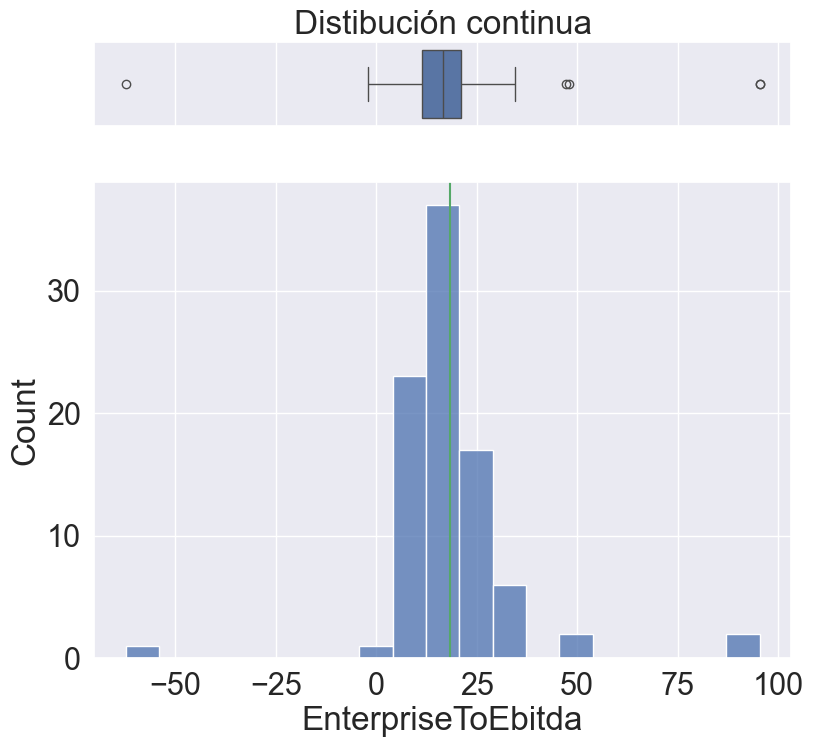

In [19]:
plot(df_winsor['EnterpriseToEbitda'])

In [24]:
df_winsor.describe().T

,count,mean,std,min,25%,50%,75%,max
Beta,100.0,8.866500e-01,0.474125,0.010000,0.421750,0.911500,1.222500,2.375000
DividendYield,89.0,2.252693e+00,1.493317,0.019700,0.890000,2.220000,3.010000,6.520000
EnterpriseToEbitda,89.0,1.814185e+01,16.669335,-64.613000,11.402000,16.068000,21.444000,94.362000
ReturnOnAssets,100.0,7.826270e-02,0.072357,-0.019990,0.034205,0.062805,0.109047,0.511880
profitMargins,100.0,1.782499e-01,0.128786,-0.234380,0.084505,0.159300,0.283062,0.556030
operatingMargins,100.0,2.445084e-01,0.153445,-0.066900,0.123073,0.244905,0.340473,0.682960
currentRatio,94.0,1.458053e+00,0.905224,0.366000,0.922500,1.146500,1.800250,4.875000
revenueGrowth,100.0,9.405000e-02,0.114172,-0.091000,0.033250,0.090500,0.136750,0.571000
shortPercentOfFloat,99.0,1.974141e-02,0.010228,0.007400,0.012550,0.017700,0.023400,0.058000
PriceToBook_Transformed,100.0,2.630525e-02,0.141471,-0.394669,-0.015335,0.015637,0.069507,0.383544


# Variables Categoricas

In [27]:
df_non_numeric = df.select_dtypes(exclude='number')

In [28]:
# Valores unicos
df_non_numeric.nunique()

Ticker    100
Sector     10
dtype: int64

In [29]:
# Convertir Sector a category
df_non_numeric['Sector'] = df_non_numeric['Sector'].astype('category')

In [30]:
df_non_numeric['Sector'].value_counts()

Sector
Financial Services        21
Healthcare                18
Technology                16
Industrials               12
Consumer Defensive        11
Consumer Cyclical          8
Communication Services     4
Basic Materials            4
Energy                     3
Utilities                  3
Name: count, dtype: int64

In [31]:
# Merge de variables continuas transformadas y variables no numericas
df_final = pd.concat([df_non_numeric, df_winsor], axis=1)

In [32]:
df_final

,Ticker,Sector,Beta,DividendYield,EnterpriseToEbitda,ReturnOnAssets,profitMargins,operatingMargins,currentRatio,revenueGrowth,shortPercentOfFloat,PriceToBook_Transformed,returnOnEquity_Transformed,ForwardPE_log,MarketCap_log,debtToEquity_log,trailingPegRatio_log
0,AAPL,Technology,1.116,0.40,24.875,0.24377,0.27037,0.35374,0.974,0.157,0.0091,0.383544,1.972359,3.322044,8.238571,4.631130,0.846340
1,MSFT,Technology,1.108,0.89,17.520,0.14860,0.39044,0.47094,1.386,0.167,0.0076,0.056416,0.411225,3.077516,8.019463,3.451225,0.292520
2,GOOG,Communication Services,1.112,0.28,23.630,0.15427,0.32810,0.31568,2.005,0.180,NaN,0.066554,0.452481,3.101115,8.191057,2.780867,0.817840
3,AMZN,Consumer Cyclical,1.420,NaN,16.087,0.06928,0.10834,0.10533,1.051,0.136,0.0090,0.030957,-0.031754,3.128117,7.735780,3.771266,0.693897
4,NVDA,Technology,2.375,0.02,32.049,0.51188,0.55603,0.65024,3.905,0.571,0.0109,0.250624,1.615205,2.806592,8.371454,1.981691,0.106610
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,ALL,Financial Services,0.206,2.03,4.737,0.06490,0.15191,0.29017,0.366,0.051,0.0252,-0.015224,0.565830,2.131434,4.009234,3.222509,-0.748871
96,MET,Financial Services,0.745,3.16,14.606,0.00458,0.04384,0.04670,1.895,0.276,0.0191,-0.019022,-0.521927,1.881705,3.857106,5.420420,-0.534606
97,PRU,Financial Services,0.966,5.61,7.675,0.00424,0.05840,0.10410,0.916,0.312,0.0268,-0.027913,-0.558029,1.838005,3.520395,4.824161,-0.588247
98,PNC,Financial Services,0.974,3.30,NaN,0.01234,0.31075,0.39262,NaN,0.096,0.0177,-0.021716,-0.514457,2.300963,4.422895,NaN,0.828857


# Missings

In [35]:
df_final.isnull().sum()

Ticker                         0
Sector                         0
Beta                           0
DividendYield                  0
EnterpriseToEbitda            11
ReturnOnAssets                 0
profitMargins                  0
operatingMargins               0
currentRatio                   6
revenueGrowth                  0
shortPercentOfFloat            1
PriceToBook_Transformed        0
returnOnEquity_Transformed     5
ForwardPE_log                  0
MarketCap_log                  0
debtToEquity_log              13
trailingPegRatio_log           5
dtype: int64

In [34]:
# DividendYield: imputar 0
df_final['DividendYield'] = df_final['DividendYield'].fillna(0)

In [38]:
# Ratios
df_cont = df_final.select_dtypes(include='number')
# Imputador: Chain equations
imputer_itImp = skl_imp.IterativeImputer(max_iter=10, random_state=0)

In [40]:
df_imputed = pd.DataFrame(imputer_itImp.fit_transform(df_cont),columns=df_cont.columns)
df_imputed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Beta                        100 non-null    float64
 1   DividendYield               100 non-null    float64
 2   EnterpriseToEbitda          100 non-null    float64
 3   ReturnOnAssets              100 non-null    float64
 4   profitMargins               100 non-null    float64
 5   operatingMargins            100 non-null    float64
 6   currentRatio                100 non-null    float64
 7   revenueGrowth               100 non-null    float64
 8   shortPercentOfFloat         100 non-null    float64
 9   PriceToBook_Transformed     100 non-null    float64
 10  returnOnEquity_Transformed  100 non-null    float64
 11  ForwardPE_log               100 non-null    float64
 12  MarketCap_log               100 non-null    float64
 13  debtToEquity_log            100 non-

In [41]:
df_combined = pd.concat([df_imputed, df_final.select_dtypes(exclude='number')], axis=1)

In [42]:
df_combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   Beta                        100 non-null    float64 
 1   DividendYield               100 non-null    float64 
 2   EnterpriseToEbitda          100 non-null    float64 
 3   ReturnOnAssets              100 non-null    float64 
 4   profitMargins               100 non-null    float64 
 5   operatingMargins            100 non-null    float64 
 6   currentRatio                100 non-null    float64 
 7   revenueGrowth               100 non-null    float64 
 8   shortPercentOfFloat         100 non-null    float64 
 9   PriceToBook_Transformed     100 non-null    float64 
 10  returnOnEquity_Transformed  100 non-null    float64 
 11  ForwardPE_log               100 non-null    float64 
 12  MarketCap_log               100 non-null    float64 
 13  debtToEquity_log     

In [46]:
df_combined.select_dtypes(include='number').skew()

Beta                          0.439538
DividendYield                 0.897324
EnterpriseToEbitda            0.972079
ReturnOnAssets                2.574613
profitMargins                 0.089155
operatingMargins              0.425455
currentRatio                  2.139366
revenueGrowth                 1.693880
shortPercentOfFloat           1.634173
PriceToBook_Transformed      -0.810233
returnOnEquity_Transformed    0.166670
ForwardPE_log                 0.709529
MarketCap_log                 0.791824
debtToEquity_log             -0.380927
trailingPegRatio_log          0.294491
dtype: float64

In [47]:
# Guardar datos extraidos en fichero clean_data
df_combined.to_parquet(f"{data_folder}/clean_data.parquet")